In [2]:
require(data.table)
require(tidyverse)
require(dplyr)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)
options(repr.plot.width=20, repr.plot.height=15)

# exploring number of reads output from dada2 across sequencing runs
- figured out that I was consolidating my dada2 tables incorrectly

## condolidate dada2 runs w/o run1
- is Datee_16S still significant?

-  sequence run 1, selected for the 400 band, 
- migght be that some samples were sequenced at greater depth bc there were less conc of others 


In [4]:
track2=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run2_Seqnums_16S.csv")

track3=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run3_Seqnums_16S.csv")

track4=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run4_Seqnums_16S.csv")

track5=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run5_Seqnums_16S.csv")

In [5]:
track_no1 <- bind_rows(track2, track3, track4, track5)

In [6]:
meta=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/meta_PCR.csv", header=TRUE)

## merging track and meta to run anova for what is driving reads

In [7]:
setnames(track_no1, c("V1"), c("Tubelabel_species"), skip_absent=TRUE)
# Step 1: Replace '-' with '_' in asv_clean$Tube
track_no1$Tubelabel_species <- gsub("-", "_", track_no1$Tubelabel_species)
head(track_no1)

Tubelabel_species,input,filtered,denoisedF,denoisedR,merged,nonchim
<chr>,<int>,<int>,<int>,<int>,<int>,<int>
012024_BEL_CBC_T1_559_MCAV,1377610,1219878,1217341,1217659,1205749,206754
012024_BEL_CBC_T2_591_PAST,975642,854021,822591,819017,756352,487061
012024_BEL_CBC_T2_595_PAST,1186132,1043059,1040328,1040382,1029411,508641
012024_BEL_CBC_T2_599_MCAV,1198173,1059557,1057873,1057921,1051080,401576
012024_BEL_CBC_T4_665_MCAV,968899,857250,855406,855277,845889,187812
012024_BEL_CBC_T4_669_MCAV,1265565,1120659,1118086,1118485,1103353,253311


In [8]:
#exclude samples that are not in asv_clean
track_meta_no1 <- merge(meta, track_no1, by = "Tubelabel_species", all = FALSE)

## anova base r
- do not look at Date_16S and Seq_run in the same anova beacuse they are essentially the same variable.

In [10]:
class(track_meta_no1$Seq_run)

[1] "integer"

In [11]:
track_meta_no1$Seq_run <- as.character(track_meta_no1$Seq_run)

In [13]:
class(track_meta_no1$Seq_run)

[1] "character"

In [16]:
class(track_meta_no1$Month_year)

[1] "integer"

In [17]:
unique(track_meta_no1$Seq_run)

[1] "2" "3" "4" "5"

In [18]:
# Compute the analysis of variance
nonchim.anov <- aov(nonchim ~ Date_16S + factor(Month_year) + as.factor(Seq_run) + Species + Health_status, data = track_meta_no1)
# Summary of the analysis
summary(nonchim.anov)

                    Df    Sum Sq   Mean Sq F value   Pr(>F)    
Date_16S            18 5.057e+12 2.809e+11   6.580 4.25e-14 ***
factor(Month_year)  11 1.628e+11 1.480e+10   0.347    0.974    
as.factor(Seq_run)   1 9.921e+10 9.921e+10   2.324    0.128    
Species              5 2.456e+12 4.912e+11  11.504 2.83e-10 ***
Health_status        3 1.489e+11 4.963e+10   1.162    0.324    
Residuals          339 1.447e+13 4.270e+10                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [22]:
# Compute the analysis of variance
nodate.anov <- aov(nonchim ~ factor(Month_year) + as.factor(Seq_run) + Species + Health_status, data = track_meta_no1)
# Summary of the analysis
summary(nodate.anov)

                    Df    Sum Sq   Mean Sq F value  Pr(>F)    
factor(Month_year)  11 3.806e+11 3.460e+10   0.683 0.75499    
as.factor(Seq_run)   3 6.275e+11 2.092e+11   4.128 0.00676 ** 
Species              5 3.185e+12 6.369e+11  12.569   3e-11 ***
Health_status        3 2.144e+11 7.147e+10   1.410 0.23946    
Residuals          355 1.799e+13 5.068e+10                    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [ ]:
# Compute the analysis of variance
nodate.anov <- aov(input ~ factor(Month_year) + as.factor(Seq_run) + Species + Health_status, data = track_meta_no1)
# Summary of the analysis
summary(nodate.anov)

In [19]:
table(track_meta_no1$Seq_run)
table(track_meta_no1$Seq_run[complete.cases(track_meta_no1[, c("nonchim","Date_16S","Month_year","Seq_run","Species","Health_status")])])


 2  3  4  5 
95 93 95 95 


 2  3  4  5 
95 93 95 95 

In [20]:
table(track_meta_no1$Seq_run, track_meta_no1$Date_16S)

   
    1_7_2026 1_8_2026 1_9_2026 10_14_2025 12_3_2025 12_4_2025 2_10_2026
  2        0        0        0         16         7        13         0
  3       30       30       32          0         0         1         0
  4        0        0        0          0         0         0        33
  5        0        0        0          0         0         0         0
   
    2_11_2026 2_9_2026 3_10_2026 3_11_2026 3_17_2026 3_9_2026 8_11_2025
  2         0        0         0         0         0        0         7
  3         0        0         0         0         0        0         0
  4        31       31         0         0         0        0         0
  5         0        0        31        31         2       31         0
   
    8_22_2025 8_26_2025 8_28_2025 8_8_2025 9_10_2025
  2         7         8        15        7        15
  3         0         0         0        0         0
  4         0         0         0        0         0
  5         0         0         0        0         0

In [21]:
# Check levels actually used
model.frame(nonchim.anov)$Seq_run |> table()

# Check missing data impact
sum(!complete.cases(track_meta_no1[, c("nonchim","Date_16S","Month_year","Seq_run","Species","Health_status")]))

# Check confounding
xtabs(~ Seq_run + Date_16S, data = track_meta_no1)

< table of extent 0 >

[1] 0

       Date_16S
Seq_run 1_7_2026 1_8_2026 1_9_2026 10_14_2025 12_3_2025 12_4_2025 2_10_2026
      2        0        0        0         16         7        13         0
      3       30       30       32          0         0         1         0
      4        0        0        0          0         0         0        33
      5        0        0        0          0         0         0         0
       Date_16S
Seq_run 2_11_2026 2_9_2026 3_10_2026 3_11_2026 3_17_2026 3_9_2026 8_11_2025
      2         0        0         0         0         0        0         7
      3         0        0         0         0         0        0         0
      4        31       31         0         0         0        0         0
      5         0        0        31        31         2       31         0
       Date_16S
Seq_run 8_22_2025 8_26_2025 8_28_2025 8_8_2025 9_10_2025
      2         7         8        15        7        15
      3         0         0         0        0         0
      4         0    

# potential solution to high reads in seq_run 1: consolidate dada2 runs 1-5, with rarefaction curves
## what is rarefaction?
- way to minimize towards samples that have more reads, look at read coverage instead of total reads
- randomly remove some of the coverage from the really big seqs


## notes
- Seq run r1 does not isolate specific species, and dates 2_25_2025 and 2_26_2025 do not isolate specific concentrations
- seq run 1 has super high reads compared to other 4 seq runs, perhaps due to pooling samples at 30ng and THEN selecting for a specific band. cannot verify how many ng of each sample were ultimately in the pool


In [13]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/ps_16S.rds")

ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 194639 taxa and 470 samples ]
sample_data() Sample Data:       [ 470 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 194639 taxa by 6 taxonomic ranks ]

## read count histograms

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


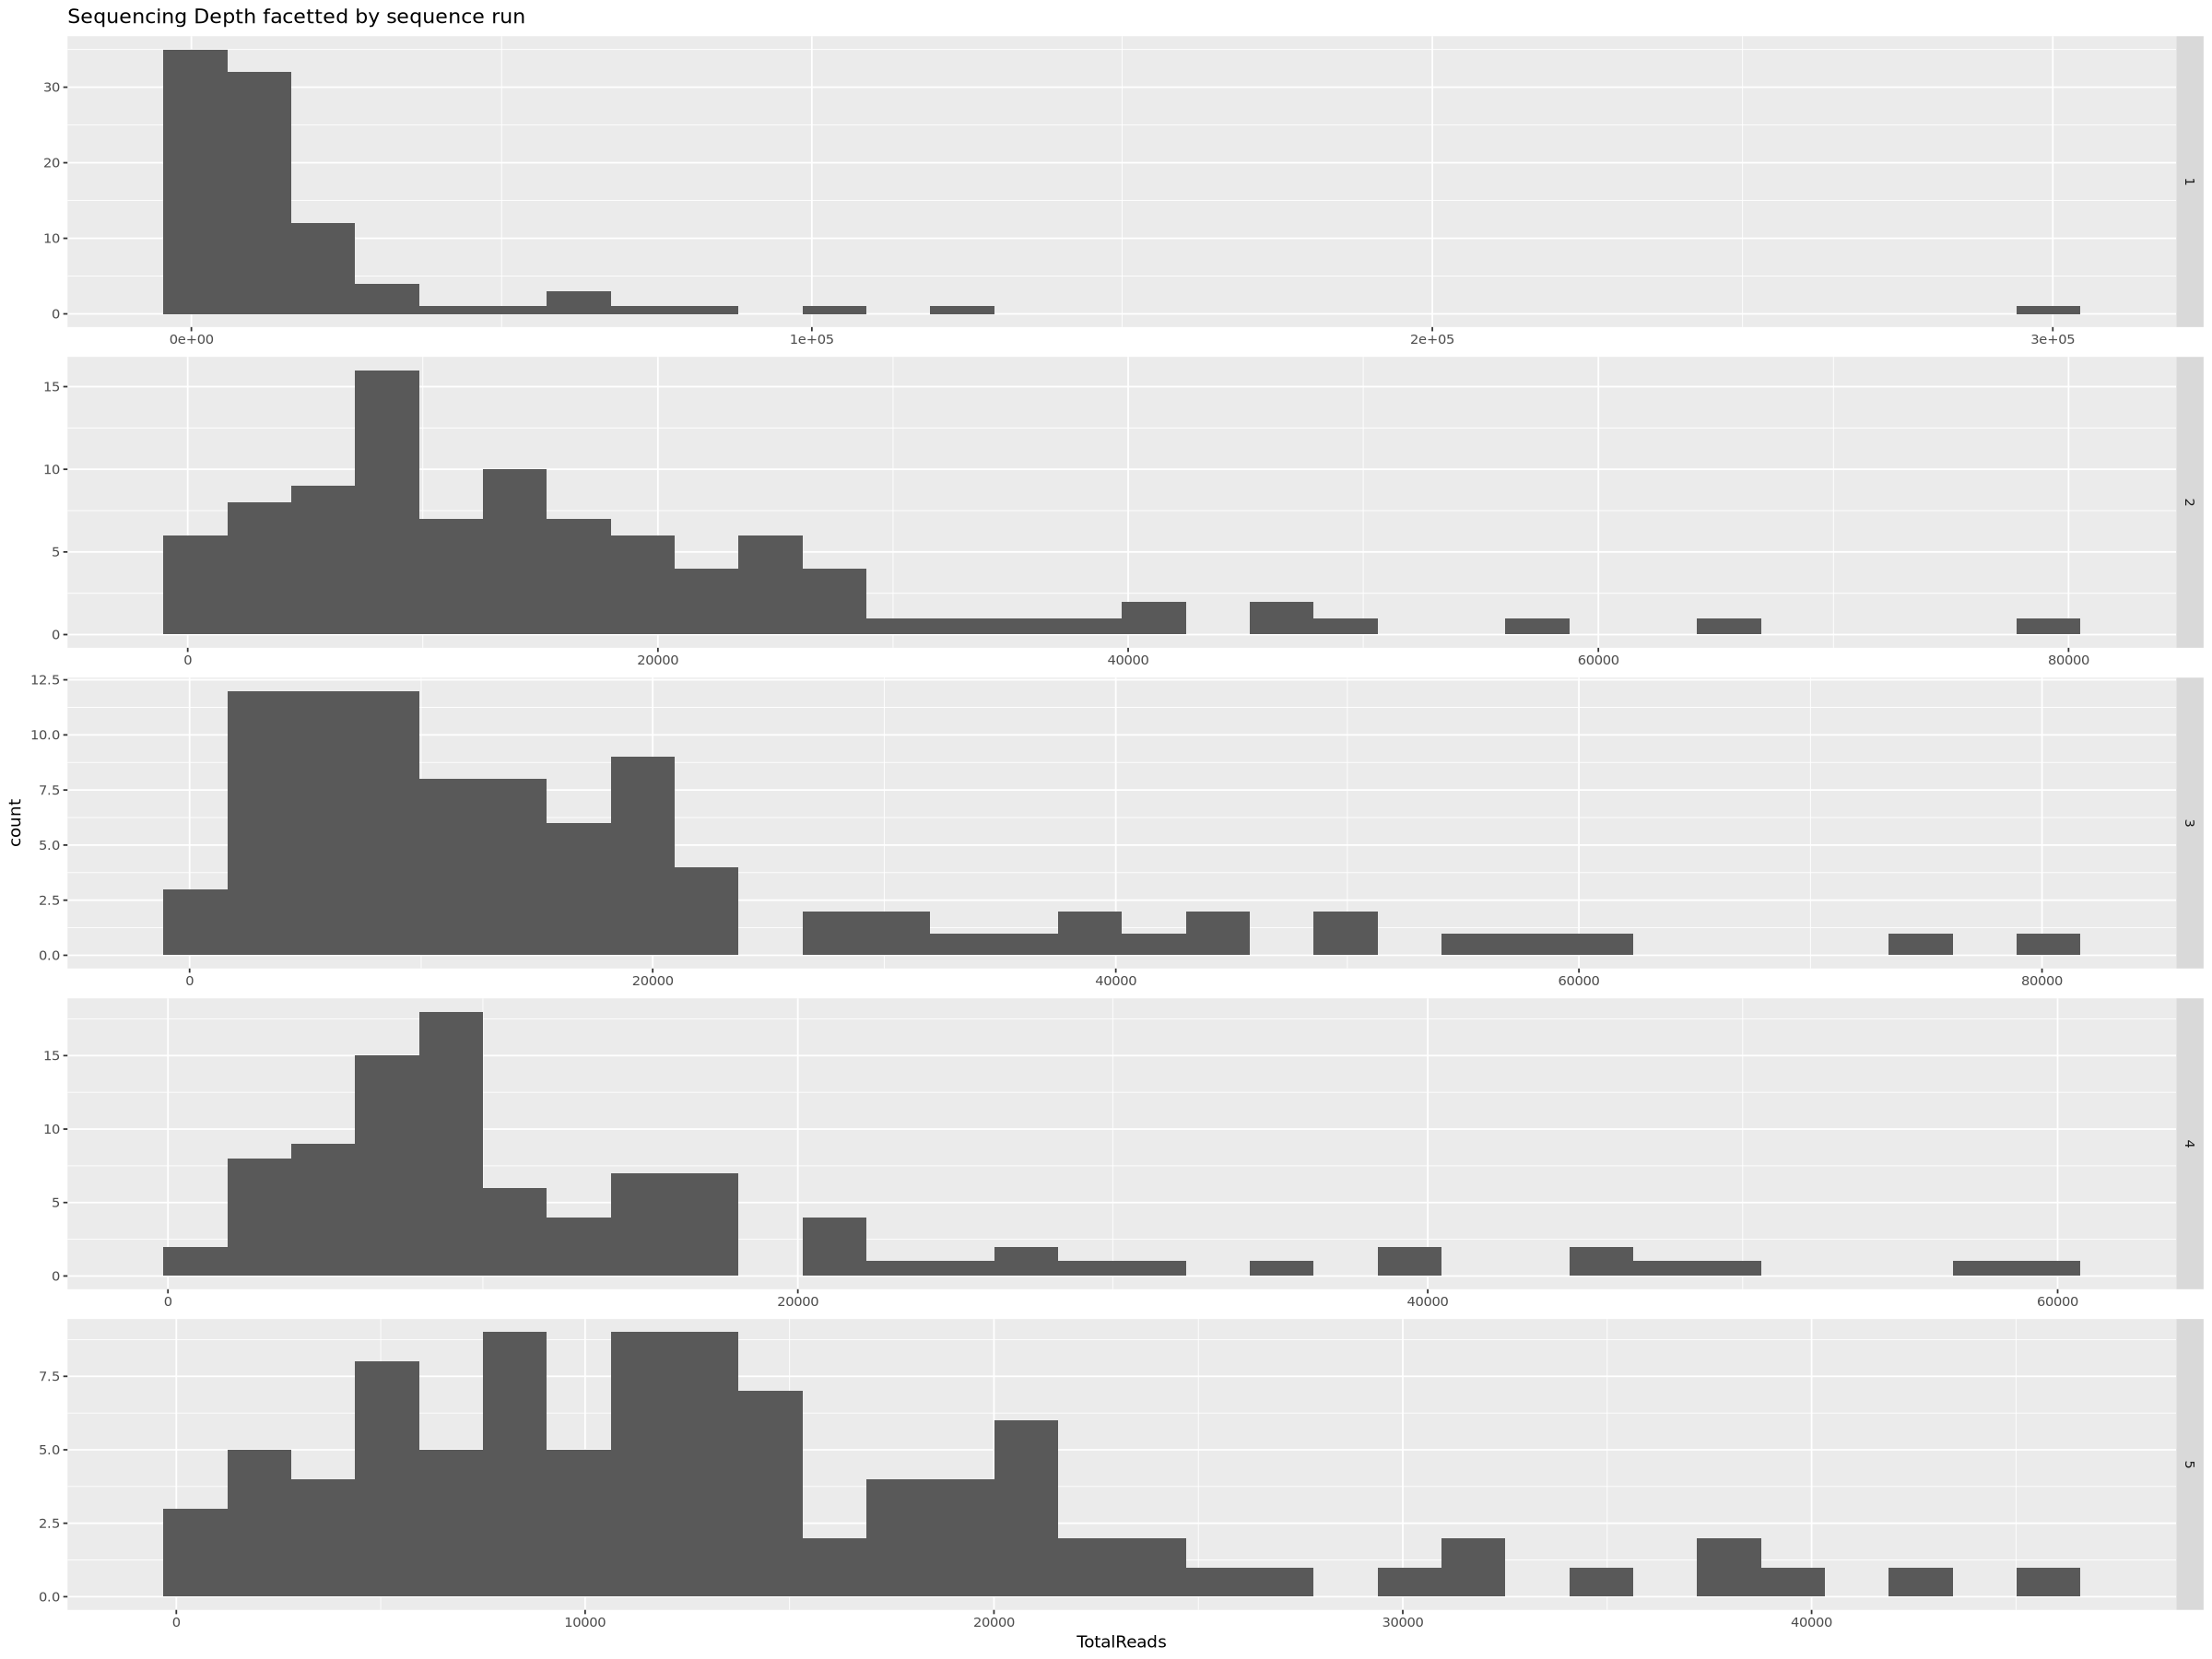

In [13]:
# Check read count
readcount = data.table(as(sample_data(ps), "data.frame"),
                 TotalReads = sample_sums(ps), 
                 keep.rownames = TRUE)
setnames(readcount, "rn", "SampleID")
ggplot(readcount, aes(TotalReads)) + geom_histogram() + ggtitle("Sequencing Depth facetted by sequence run") + facet_wrap(Seq_run ~., strip.position = "right",  ncol = 1, scales = "free")  # Set desired font size

## sample_sums 

- A named numeric-class length equal to the number of samples in the x, name indicating the sample ID, and value equal to the sum of all individuals observed for each sample in x.

- calculate sum of values across each sample

In [9]:
head(readcount)

SampleID,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,TotalReads
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<dbl>
012024_BEL_CBC_T1_557_SSID,Healthy,1_3,3_4_2025,Healthy,SSID,Jan 2024,1,CBC30N,2024-01-10,2384
012024_BEL_CBC_T1_559_MCAV,Healthy,1_24,8_22_2025,Healthy,MCAV,Jan 2024,2,CBC30N,2024-01-10,6886
012024_BEL_CBC_T1_563_PSTR,Healthy,1_12,3_6_2025,Healthy,PSTR,Jan 2024,1,CBC30N,2024-01-10,4754
012024_BEL_CBC_T1_565_PAST,Bleached_Tissue,1_21,2_10_2026,CLP,PAST,Jan 2024,4,CBC30N,2024-01-10,25965
012024_BEL_CBC_T2_585_OFAV,Healthy,2_76,2_10_2026,Healthy,OFAV,Jan 2024,4,SR30N,2024-01-12,8855
012024_BEL_CBC_T2_587_SSID,Bleached_Tissue,2_72,1_8_2026,CLB,SSID,Jan 2024,3,SR30N,2024-01-12,12039


In [6]:
total_reads <- print(readcount[order(readcount$TotalReads), c("SampleID", "TotalReads")])

                        SampleID TotalReads
                          <char>      <num>
  1:   122022_BEL_CBC_T4_34_PSTR        247
  2:  022024_BEL_CBC_T4_870_MCAV        323
  3:   062019_BEL_CBC_T3_23_PAST        465
  4:   062019_BEL_CBC_T2_25_PAST        584
  5:  022024_BEL_CBC_T3_848_MCAV        620
 ---                                       
466:  092023_BEL_CBC_T2_171_OFAV      80279
467:  092023_BEL_CBC_T1_171_PAST      83763
468: 062024_BEL_CBC_T2_1375_SSID     107345
469: 082024_BEL_CBC_T3_1562_OFAV     122042
470:  092023_BEL_CBC_T2_184_MCAV     299304


In [7]:
write.csv(total_reads, "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/total_reads.csv")

# wait a minute my phyloseq read counts are so different from dada2 nonchim??

- losing 95% of reads due to consolidating asv tables the wrong way! do not use bind_rows() for asv tables

In [16]:
readcount[, min(TotalReads)]

[1] 247

In [17]:
median(readcount$TotalReads)

[1] 11000.5

In [ ]:
mean(readcount$TotalReads)

In [14]:
sum(sample_sums(ps))

[1] 7638382

In [15]:
head(sample_sums(ps))

012024_BEL_CBC_T1_557_SSID 012024_BEL_CBC_T1_559_MCAV 
                      2384                       6886 
012024_BEL_CBC_T1_563_PSTR 012024_BEL_CBC_T1_565_PAST 
                      4754                      25965 
012024_BEL_CBC_T2_585_OFAV 012024_BEL_CBC_T2_587_SSID 
                      8855                      12039

In [16]:
summary(as.vector(otu_table(ps)))

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
    0.00     0.00     0.00     0.08     0.00 51828.00 

In [17]:
dim(otu_table(ps))

[1]    470 194639

# new way to combine asv tables from dada2 to make phyloseq object

In [ ]:
#make sure sample names are rownames
to_mat <- function(df) {
  df <- as.data.frame(df)
  rownames(df) <- df[,1]
  df <- df[,-1]
  as.matrix(df)
}

asv1 <- to_mat(asv1)
asv2 <- to_mat(asv2)
asv3 <- to_mat(asv3)
asv4 <- to_mat(asv4)
asv5 <- to_mat(asv5)

In [ ]:
#merge using dada2

all_asvs <- Reduce(union, list(
  colnames(asv1),
  colnames(asv2),
  colnames(asv3),
  colnames(asv4),
  colnames(asv5)
))

merge_asv <- function(mat, all_cols) {
  missing <- setdiff(all_cols, colnames(mat))
  if (length(missing) > 0) {
    zero_mat <- matrix(0, nrow = nrow(mat), ncol = length(missing))
    colnames(zero_mat) <- missing
    mat <- cbind(mat, zero_mat)
  }
  mat[, all_cols, drop = FALSE]
}

asv_list <- lapply(list(asv1, asv2, asv3, asv4, asv5),
                   merge_asv,
                   all_cols = all_asvs)

seqtab.all <- do.call(rbind, asv_list)

In [ ]:
#check 
sum(seqtab.all) #should be 167M reads
sum(is.na(seqtab.all)) #must be zero
nrow(seqtab.all) #475

## taxa table

In [ ]:
#make sure taxa tables are chr matrices
tax_list <- list(tax1, tax2, tax3, tax4, tax5)
tax_list <- lapply(tax_list, function(x) as.matrix(as.data.frame(x)))

In [ ]:
#build full asv

all_asvs <- Reduce(union, lapply(tax_list, rownames)) #all taxa id

In [ ]:
#align tax1 to tax2...

align_tax <- function(tax, all_asvs) {
  
  missing <- setdiff(all_asvs, rownames(tax))
  
  if (length(missing) > 0) {
    add <- matrix(NA,
                  nrow = length(missing),
                  ncol = ncol(tax))
    rownames(add) <- missing
    colnames(add) <- colnames(tax)
    tax <- rbind(tax, add)
  }
  
  tax[all_asvs, , drop = FALSE]
}

In [ ]:
#merge all runs
tax.all <- Reduce(function(x, y) align_tax(x, all_asvs), ## all sequence ids from taxonomy
                  tax_list)

In [ ]:
#check
any(duplicated(rownames(tax.all))) #no dupes

#full coverage
length(setdiff(all_asvs, rownames(tax.all))) #should be 0

#any missing
colSums(is.na(tax.all))